# Machine learning analysis

Importing modules and data

In [1]:
import descriptive as desc
from IPython.display import display,Markdown #,HTML
from statsmodels.formula.api import ols
import statsmodels.api as sm
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from scipy.stats import pearsonr
import scipy.stats as st
import sympy
from sklearn.datasets import load_iris
import scipy.stats as st
from sklearn import neighbors
from sklearn import svm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.colors import ListedColormap
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

---
## Analysis 1
Method      : Regression  
Data related: Grade, with all IVs   
Objective   : Relationship between grade and multiple variables using linear regression.

In [2]:

X_train_const = sm.add_constant(desc.X_train)
model = sm.OLS(desc.y_train, X_train_const)
results = model.fit()

coef_table = pd.DataFrame({
    "coef": results.params,
    "std_err": results.bse,
    "t": results.tvalues,
    "p_value": results.pvalues
}).sort_values("p_value")

coef_table


,coef,std_err,t,p_value
const,14.233157,3.534580,4.026832,0.000074
failures,-1.114200,0.369245,-3.017505,0.002796
study,0.704894,0.294951,2.389869,0.017551
Medu,0.509508,0.277634,1.835177,0.067596
age,-0.360805,0.197485,-1.827000,0.068820
travel,-0.583413,0.346026,-1.686038,0.092961
freetime,0.269879,0.254940,1.058597,0.290744
go_out,-0.195484,0.222073,-0.880269,0.379508
Fedu,0.190154,0.275048,0.691348,0.489950
absences,0.022768,0.033870,0.672234,0.502018


### Brief discussion 1

Here, we see some of the p-value is over 0.05, so we reduce a variable until all vaiables' p-value are lower than 0.05.

In [3]:

X = desc.X_train
X2= desc.X_test
y = desc.y_train

while True:
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()
    p_values = model.pvalues
    max_p = p_values.max()
    max_p_col = p_values.idxmax()
    if max_p <= 0.05:
        break
    print(f"Removing {max_p_col} (p-value: {max_p:.4f})")
    X = X.drop(columns=[max_p_col])
    X2 = X2.drop(columns=[max_p_col])
    if X.shape[1] == 0:
        break

coef_table = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "t": model.tvalues,
    "p_value": model.pvalues
}).sort_values("p_value")

coef_table

Removing absences (p-value: 0.5020)
Removing Fedu (p-value: 0.4882)
Removing go_out (p-value: 0.4065)
Removing freetime (p-value: 0.4223)
Removing travel (p-value: 0.0663)


,coef,std_err,t,p_value
const,14.348644,3.296187,4.353104,0.000019
failures,-1.149120,0.364451,-3.153016,0.001798
Medu,0.673390,0.225905,2.980859,0.003136
study,0.692519,0.287186,2.411392,0.016557
age,-0.389290,0.191789,-2.029778,0.043356


### Validation 1

In [4]:
X_test_const = sm.add_constant(X2)
y_pred = model.predict(X_test_const)

y_pred_train = model.predict(sm.add_constant(X))

r2_train = r2_score(desc.y_train, y_pred_train)
r2_test = r2_score(desc.y_test, y_pred)
mse_test = mean_squared_error(desc.y_test, y_pred)

pd.Series({"R2_train": r2_train, "R2_test": r2_test, "MSE_test": mse_test})

R2_train     0.147757
R2_test      0.081277
MSE_test    25.658582
dtype: float64

R2 is quite low in both training and test, also MSE exceeds 20, grade's range, meaning limited predictive performance. This suggests that remaining four factors (failures, Mother's education, studytime, age) are significantly associated with grade, while a substancial portion of the variation remains unexplained.

### Visualization 1

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Validation: Observed vs Predicted Grade (test data)</span></p><br><br>

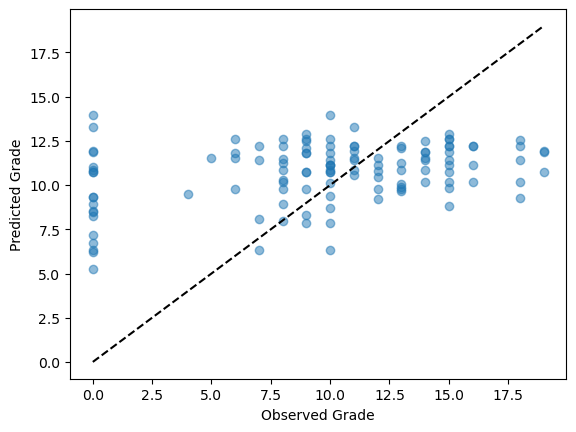

In [5]:
def validation_plot(num=1):
    plt.scatter(desc.y_test, y_pred, alpha=0.5)
    plt.plot([desc.y_test.min(), desc.y_test.max()],
             [desc.y_test.min(), desc.y_test.max()],
             'k--')
    plt.xlabel("Observed Grade")
    plt.ylabel("Predicted Grade")
    desc.display_title("Validation: Observed vs Predicted Grade (test data)", pref='Figure', num=num)

validation_plot()
plt.show()

Explanation, maybe

---
## Analysis 2
Method      : classification  
Data related: Grade, and all IVs    
Objective   : explore classification performance using validation.

## Note of what is going on
1. Plot data on (Mother's education, absence) axis, marking pass/ fail of them.
2. Learn the data by ANN, alpha being 0.01.
3. Check whether the model fit well in both training and test data.
4. Check how alpha changes model's fitness
5. Check by how much percent the model predict pass/ fail.
6. Try to improve rate by standerization
7. See the model's dicision surface
8. Check by how much percent the model predict pass/ fail.

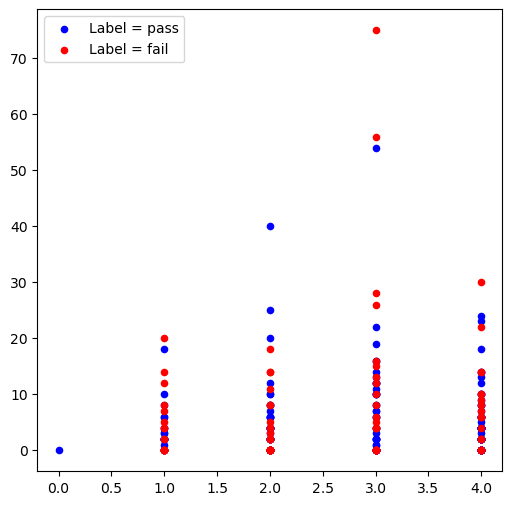

In [6]:
X = desc.Xc_train

X["labels"] = X["pf"]
x0     = X[X["labels"] == 1]  # features for all observations in Group "pass"
x1     = X[X["labels"] == 0]  # features for all observations in Group "fail"

plt.figure(figsize=(6,6))
ax     = plt.axes()
colors = ['b','r']
ax.scatter( x0.iloc[:,2], x0.iloc[:,9], color=colors[0], s=20, label='Label = pass' )
ax.scatter( x1.iloc[:,2], x1.iloc[:,9], color=colors[1], s=20, label='Label = fail' )
ax.set_xlabel('', size=14)
ax.set_ylabel('', size=14)
ax.legend()
plt.show()

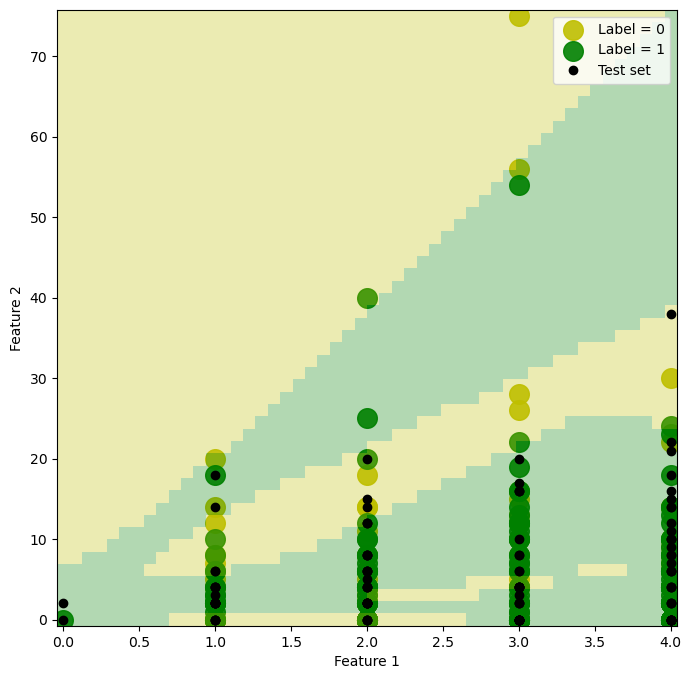

In [7]:
def plot_decision_surface(classifier, x, labels, ax=None, colors=None, n=50, alpha=0.3, marker_size=200, marker_alpha=0.9):
    nlabels   = np.unique( labels ).size
    colors    = plt.cm.viridis( np.linspace(0,1,nlabels) )  if (colors is None) else colors
    ax        = plt.gca() if (ax is None) else ax
    xmin,xmax = x.min(axis=0), x.max(axis=0)
    Xp,Yp     = np.meshgrid( np.linspace(xmin.iloc[0],xmax.iloc[0],n) , np.linspace(xmin.iloc[1],xmax.iloc[1],n) )
    xp        = np.vstack( [Xp.flatten(), Yp.flatten()] ).T
    xp_df = pd.DataFrame(xp, columns=x.columns) 
    labelsp   = classifier.predict(xp_df)
    Labelsp   = np.reshape(labelsp, Xp.shape)
    cmap      = ListedColormap(colors)
    for i,label in enumerate( np.unique(labels) ):
        xx   = x[labels==label]
        ax.scatter( xx.iloc[:,0], xx.iloc[:,1], color=colors[i], s=marker_size, alpha=marker_alpha, label=f'Label = {label}' )
    plt.pcolormesh(Xp, Yp, Labelsp, cmap=cmap, alpha=alpha)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    
X_2d = X.iloc[:, [2, 9]]

# create and train a classifier:
mlp    = MLPClassifier(solver='lbfgs', alpha=0.01, hidden_layer_sizes=(50, 20), random_state=0, max_iter=5000)
mlp.fit(X_2d, desc.yc_train)

# plot the decision surface:
plt.figure(figsize=(8,8))
plot_decision_surface(mlp, X_2d, desc.yc_train, colors = ['y', 'g'])
plt.plot(desc.Xc_test.iloc[:,2], desc.Xc_test.iloc[:,9], 'ko', label='Test set')
plt.legend()
plt.show()

In [8]:
labels_pred_train = mlp.predict(X.iloc[0:, [2, 9]])
labels_pred_test  = mlp.predict(desc.Xc_test.iloc[0:, [2, 9]])
cr_train          = accuracy_score(desc.yc_train, labels_pred_train)
cr_test           = accuracy_score(desc.yc_test, labels_pred_test)
print( f'Classification rate (training) = {cr_train}' )
print( f'Classification rate (test)     = {cr_test}' )

print(sum(desc.yc_train)/ len(desc.yc_train))
print(sum(desc.yc_test) / len(desc.yc_test))

Classification rate (training) = 0.7101449275362319
Classification rate (test)     = 0.6890756302521008
0.6630434782608695
0.6890756302521008


In [9]:
"""
import warnings
warnings.filterwarnings('ignore')   # this will suppress warning from sklearn

ALPHA   = [0.0001, 0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1, 2, 3, 5, 10, 20, 50, 100]
niter   = 10   # number of iterations for each ALPHA value

np.random.seed(0)

CR      = []
for alpha in ALPHA:
    cr  = []
    for i in range(niter):
        x_train, x_test, labels_train, labels_test = train_test_split(desc.Xc.iloc[:, [2, 9]], desc.yc, test_size=0.33)
        mlp    = MLPClassifier(solver='lbfgs', alpha=alpha, hidden_layer_sizes=(50, 20), max_iter=1000)
        mlp.fit(x_train, labels_train)
        labels_pred_test  = mlp.predict(x_test)
        cr_test           = accuracy_score(labels_test, labels_pred_test)
        cr.append( cr_test )
    CR.append( cr )

CR1      = np.array(CR)
"""
print()

In [10]:
"""
plt.figure()
ax = plt.axes()
h0 = ax.plot(ALPHA, CR1, 'k.', ms=3)[0]
h1 = ax.plot(ALPHA, CR1.mean(axis=1), 'k-', lw=3, label='Average CR')[0]
ax.legend([h0,h1], ['Single classifier', 'Average performance'])
ax.set_xlabel('alpha', size=16)
ax.set_ylabel('CR', size=16)
plt.show()
"""
print()

## Note:
I put this screenshot here instead of analysing each time because this analysis takes too much time every time I re-run all cells. 
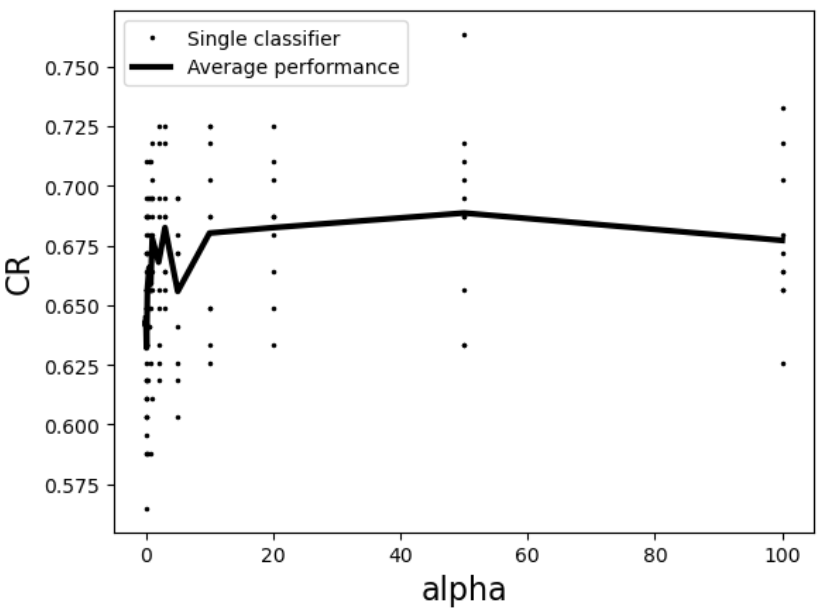

In [11]:
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score

labels_pred_test = mlp.predict(desc.Xc_test.iloc[:, [2, 9]]) 

cm = confusion_matrix(desc.yc_test, labels_pred_test)
bal = balanced_accuracy_score(desc.yc_test, labels_pred_test)

print("Balanced accuracy (test):", bal)
print("Confusion matrix (test):\n", cm)
print(classification_report(desc.yc_test, labels_pred_test, digits=3))

Balanced accuracy (test): 0.5741595253790376
Confusion matrix (test):
 [[10 27]
 [10 72]]
              precision    recall  f1-score   support

           0      0.500     0.270     0.351        37
           1      0.727     0.878     0.796        82

    accuracy                          0.689       119
   macro avg      0.614     0.574     0.573       119
weighted avg      0.657     0.689     0.657       119



In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

X_train_2d = desc.Xc_train.iloc[:, [2, 9]]
X_test_2d  = desc.Xc_test.iloc[:, [2, 9]]

mlp2 = make_pipeline(
    StandardScaler(),
    MLPClassifier(solver='lbfgs', alpha=0.0001,
                  hidden_layer_sizes=(50, 20),
                  random_state=0, max_iter=5000)
)

mlp2.fit(X_train_2d, desc.yc_train)
pred2 = mlp2.predict(X_test_2d)

print(confusion_matrix(desc.yc_test, pred2))
print("Balanced accuracy:", balanced_accuracy_score(desc.yc_test, pred2))
print(classification_report(desc.yc_test, pred2, digits=3))


[[10 27]
 [ 9 73]]
Balanced accuracy: 0.5802570863546473
              precision    recall  f1-score   support

           0      0.526     0.270     0.357        37
           1      0.730     0.890     0.802        82

    accuracy                          0.697       119
   macro avg      0.628     0.580     0.580       119
weighted avg      0.667     0.697     0.664       119



<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Pass/ Fail Distribution in 2D: Mother’s Education vs Absences (with test set)</span></p><br><br>

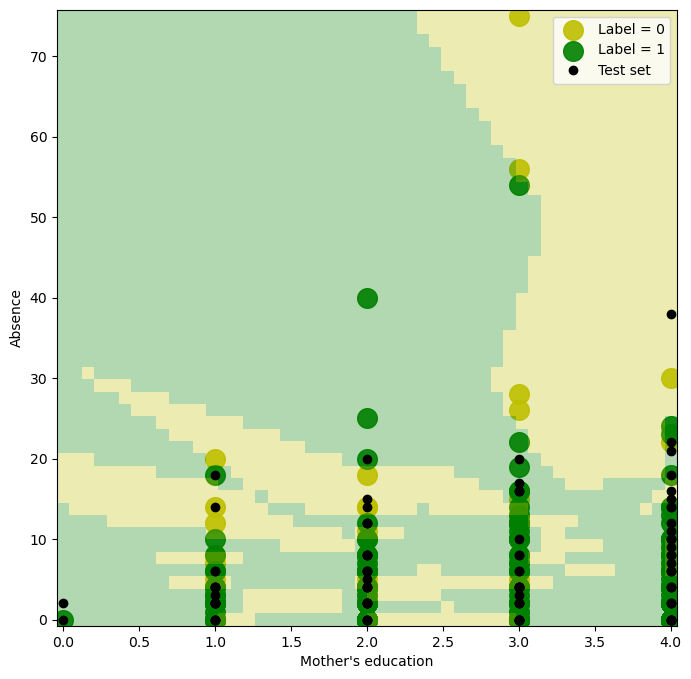

In [13]:
def decition_surface(num=1):
    plt.figure(figsize=(8,8))
    plot_decision_surface(mlp2, X_2d, desc.yc_train, colors = ['y', 'g'])
    plt.plot(desc.Xc_test.iloc[:,2], desc.Xc_test.iloc[:,9], 'ko', label='Test set')
    desc.display_title("Pass/ Fail Distribution in 2D: Mother’s Education vs Absences (with test set)", pref='Figure', num=num)
    plt.legend()
    plt.ylabel("Absence")
    plt.xlabel("Mother's education")
    plt.show()

decition_surface()

In [14]:
labels_pred_train = mlp2.predict(X.iloc[0:, [2, 9]])
labels_pred_test  = mlp2.predict(desc.Xc_test.iloc[0:, [2, 9]])
cr_train          = accuracy_score(desc.yc_train, labels_pred_train)
cr_test           = accuracy_score(desc.yc_test, labels_pred_test)
print( f'Classification rate (training) = {cr_train}' )
print( f'Classification rate (test)     = {cr_test}' )

print(sum(desc.yc_train)/ len(desc.yc_train))
print(sum(desc.yc_test) / len(desc.yc_test))

Classification rate (training) = 0.75
Classification rate (test)     = 0.6974789915966386
0.6630434782608695
0.6890756302521008


---
---
---
---
---
## Analysis a template
Method      : Regression  
Data related: Grade, study time, absences, and failures  
Objective   : To make a model that predict...

### Brief discussion a

Discussion

### Visualization a